# 04 — Browse a tree, read netCDF

**Access pattern: a browsable HTTPS directory of netCDF files.** No query language, no
search index, no object-store API. Just a path, and files you can fetch. Argo's GDAC
(global data assembly centre) is the reference example, and so is much of the climate
archive.

**One thing to say up front, because it would otherwise be a surprise:** the float used
here, `1900063`, is in the **North Atlantic** (24–27 N, 22–18 W) and its cycles run
2002–2004. It is not near Monterey Bay. It is here because it is a small, complete and
well-formed example of the *file structure*, which is what this notebook teaches. The
cost of that compromise is stated in section 5 — it is worth reading.

In [1]:
import sys
from pathlib import Path

# notebooks/ holds _fetch.py and _sources.py; src/ holds the project's own helpers.
for p in (Path.cwd(), Path.cwd() / ".." / "src"):
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p.resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import _fetch
import _sources as S

# A real requests.Session, with a disk cache. Everything you use below -- .get,
# .text, .content, .json, .status_code, .raise_for_status, params= -- is
# ordinary `requests`. The cache is invisible at the call site.
http = _fetch.session()

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

_fetch.OFFLINE and print("offline mode: serving prefetched responses")

False

## 1. The directory is HTML, and that is fine

There is no listing API. You fetch the directory and read the links. An HTML parser is
overkill for a list of `href`s, so a regex is both sufficient and easier to read.

In [2]:
import re

listing = http.get(S.ARGO_DIR).text
links = re.findall(r'href="([^"?/][^"]*)"', listing)
files = [l for l in links if l.endswith((".nc", ".txt"))]

print(f"  {len(files)} files in {S.ARGO_FLOAT}/")
for f in files:
    print("   ", f)

  4 files in 1900063/
    1900063_Rtraj.nc
    1900063_meta.nc
    1900063_prof.nc
    1900063_tech.nc


| file | size | what it holds |
|---|---|---|
| `_prof.nc` | 689,348 B | **all 98 cycles** of temperature, salinity, pressure — the data |
| `_meta.nc` | 34,900 B | float configuration: launch date, PI, serial number |
| `_tech.nc` | 2,855,864 B | instrument metadata, 10,976 parameters |

The aggregated `_prof.nc` is the right granularity. The alternative — one file per cycle
— means 98 requests and 98 chances to get a partial result.

In [3]:
import xarray as xr

p = Path.cwd() / "_argo_1900063_prof.nc"
p.write_bytes(http.get(S.ARGO_FILES["prof"]).content)
ds = xr.open_dataset(p)

print("  dims:", dict(ds.sizes))
print("  PRES:", ds.PRES.dtype, ds.PRES.shape, ds.PRES.attrs.get("units"))
print("  TEMP:", ds.TEMP.dtype, ds.TEMP.shape, ds.TEMP.attrs.get("units"))
print("  PSAL:", ds.PSAL.dtype, ds.PSAL.shape, ds.PSAL.attrs.get("units"))
print("  JULD:", ds.JULD.dtype, ds.JULD.shape, "->", str(ds.JULD.values[0])[:10],
      "..", str(ds.JULD.values[-1])[:10])

  dims: {'N_PROF': 98, 'N_PARAM': 3, 'N_LEVELS': 92, 'N_CALIB': 1, 'N_HISTORY': 0}
  PRES: float32 (98, 92) decibar
  TEMP: float32 (98, 92) degree_Celsius
  PSAL: float32 (98, 92) psu
  JULD: datetime64[ns] (98,) -> 2002-03-06 .. 2004-10-31


### ⚠️ Trap — `N_PARAM` exists but does not index the data

`N_PARAM` is in `ds.sizes` with value 3, and `STATION_PARAMETERS` is shaped
`(N_PROF, N_PARAM)`. The natural assumption is that `TEMP` is
`(N_PROF, N_LEVELS, N_PARAM)` and you index all three.

It is not. This is the **v1.0** file format, where temperature, salinity and pressure
are already split into separate variables of shape `(N_PROF, N_LEVELS)`, while
`N_PARAM` is a leftover from the v2.4 stacked format.

```python
ds.TEMP.isel(N_PROF=0, N_PARAM=0)
# ValueError: Dimensions {'N_PARAM'} do not exist.
```

So: **check `.shape` before you index.** The dimension list is not a contract about
which variables use it.

In [4]:
print("  N_PARAM is in ds.sizes:", "N_PARAM" in ds.sizes, "=", ds.sizes.get("N_PARAM"))
print("  STATION_PARAMETERS shape:", ds.STATION_PARAMETERS.shape)
print("  TEMP shape              :", ds.TEMP.shape, " <- no N_PARAM")
print()
try:
    ds.TEMP.isel(N_PROF=0, N_PARAM=0)
except ValueError as exc:
    print("  ds.TEMP.isel(N_PROF=0, N_PARAM=0) ->")
    print("   ", str(exc)[:96])
print()
print("  STATION_PARAMETERS is a byte array too:")
print("   ", ds.STATION_PARAMETERS.values.ravel()[:3])

  N_PARAM is in ds.sizes: True = 3
  STATION_PARAMETERS shape: (98, 3)
  TEMP shape              : (98, 92)  <- no N_PARAM

  ds.TEMP.isel(N_PROF=0, N_PARAM=0) ->
    Dimensions {'N_PARAM'} do not exist. Expected one or more of ('N_PROF', 'N_LEVELS')

  STATION_PARAMETERS is a byte array too:
    [b'TEMP            ' b'PSAL            ' b'PRES            ']


### ⚠️ Trap — Argo QC flags are **bytes**, and comparing them to an int is all-False

Every measurement has a quality-control flag: `1` good, `2` probably good, `3` bad,
`4` bad, `5` value changed, `9` missing. In the aggregated `_prof.nc` they are stored as
**characters**, so `xarray` gives you an object array of `numpy.bytes_`.

```python
ds.PRES_QC == 1      # -> array([False, False, False, ...])
```

No exception. No warning. It reads as "nothing passed QC", which is a conclusion you
would happily believe and act on.

Why it happens: the per-cycle `.nc` / `_D` byte files store flags as `int8`, so code
written against those works fine until it meets an aggregated file. **The encoding
depends on which file you opened.**

```python
>>> np.asarray(ds.PRES_QC.values).ravel()[:4]
array([b'1', b'1', b'1', b'1'], dtype=object)
>>> (np.asarray(ds.PRES_QC.values) == 1).all()
np.False_
```

In [5]:
qc = ds["PRES_QC"].values
print("  dtype       :", qc.dtype)
print("  first values:", qc.ravel()[:4])
print()
print("  the bug, live:")
print("    (qc == 1).all()  ->", (qc == 1).all())
print("    (qc == b'1').all() ->", (qc == b"1").all())
print()
print("  Neither of those is the right test, because a single bad value makes .all()")
print("  False anyway. Decode to ints, then count:")

def decode_qc(arr):
    """Argo QC flags: int8 in the per-cycle files, characters in the aggregated file."""
    a = np.asarray(arr)
    if a.dtype.kind in "iu":                      # already numeric
        return a.astype(int)
    flat = [int(v.decode()) if isinstance(v, (bytes, np.bytes_)) and v.isdigit()
            else -1 for v in a.ravel()]
    return np.array(flat, dtype=int).reshape(a.shape)

codes = decode_qc(qc)
values, counts = np.unique(codes, return_counts=True)
lookup = {0: "no QC", 1: "good", 2: "probably good", 3: "bad", 4: "bad",
          5: "value changed", 6: "below range", 7: "above range", 8: "range differs",
          9: "missing"}
for v, n in zip(values, counts):
    print(f"    QC {v:>2}  {lookup.get(v, '?'):16} {n:>7,}  ({n / codes.size:5.1%})")

good = codes == 1
print()
print(f"  good values: {good.sum():,} of {codes.size:,}  ({good.sum() / codes.size:.1%})")
print("  -> 1 means GOOD. So the correct test is (decoded == 1), not (raw == 1).")

  dtype       : object
  first values: [b'1' b'1' b'1' b'1']

  the bug, live:
    (qc == 1).all()  -> False
    (qc == b'1').all() -> False

  Neither of those is the right test, because a single bad value makes .all()
  False anyway. Decode to ints, then count:
    QC -1  ?                    140  ( 1.6%)
    QC  1  good               8,876  (98.4%)

  good values: 8,876 of 9,016  (98.4%)
  -> 1 means GOOD. So the correct test is (decoded == 1), not (raw == 1).


## 2. One profile

Take the first cycle: pressure, temperature and salinity against depth.

In [6]:
prof = 0
p_dbar = ds.PRES.isel(N_PROF=prof).values
temp = ds.TEMP.isel(N_PROF=prof).values
sal = ds.PSAL.isel(N_PROF=prof).values
keep = ~np.isnan(p_dbar)

print(f"  cycle {prof} at {str(ds.JULD.values[prof])[:10]}")
print(f"  {keep.sum()} levels,  {p_dbar[keep].min():.0f} - {p_dbar[keep].max():.0f} dbar")
print(f"  temperature {temp[keep].min():.2f} - {temp[keep].max():.2f} C")
print(f"  salinity    {sal[keep].min():.2f} - {sal[keep].max():.2f} PSU")

  cycle 0 at 2002-03-06
  91 levels,  15 - 1988 dbar
  temperature 4.20 - 20.18 C
  salinity    35.08 - 36.96 PSU


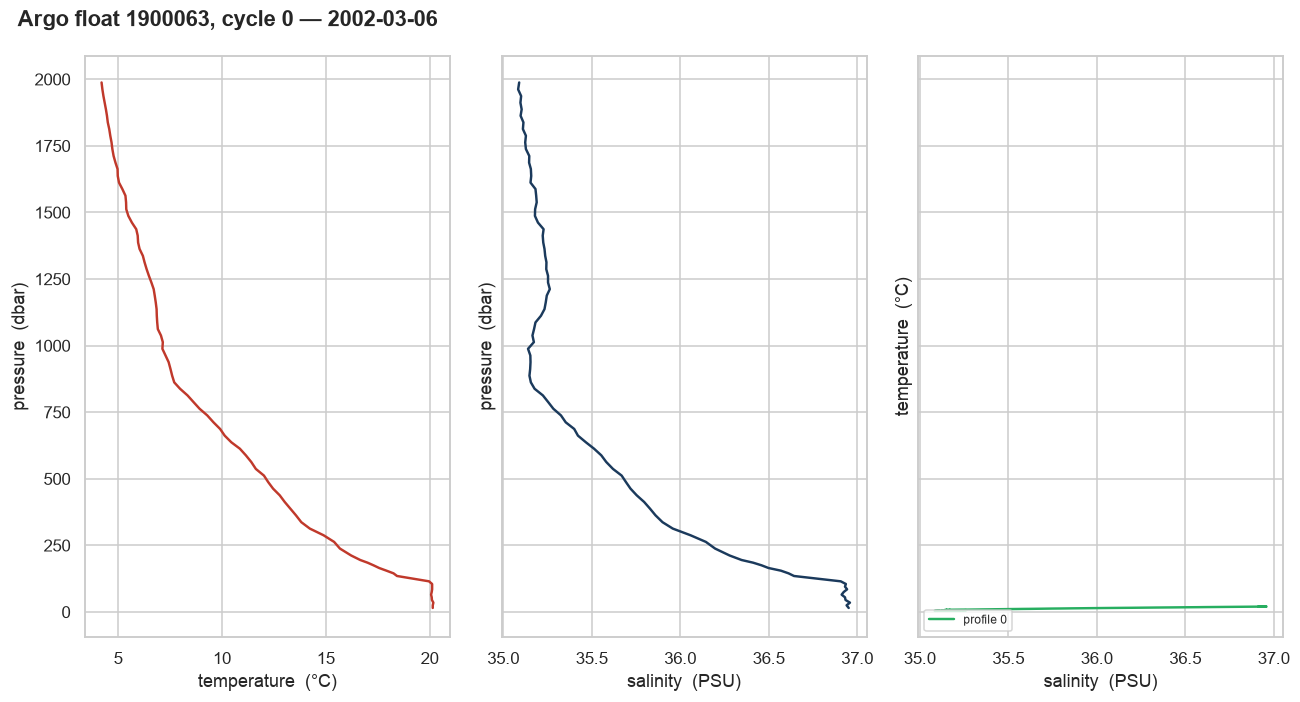

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6.5), sharey=True)
depth = p_dbar[keep]

axes[0].plot(temp[keep], depth, color="#c0392b", lw=1.6)
axes[0].set_xlabel("temperature  (°C)")

axes[1].plot(sal[keep], depth, color="#1b3a5c", lw=1.6)
axes[1].set_xlabel("salinity  (PSU)")

axes[2].plot(sal[keep], temp[keep], color="#27ae60", lw=1.6)
axes[2].set_xlabel("salinity  (PSU)")
axes[2].set_ylabel("temperature  (°C)")

for ax in axes[:2]:
    ax.set_ylabel("pressure  (dbar)")
    ax.invert_yaxis()
axes[2].legend(["profile 0"], loc="lower left", fontsize=8)

fig.suptitle(f"Argo float {S.ARGO_FLOAT}, cycle {prof} — {str(ds.JULD.values[prof])[:10]}",
             x=0.02, ha="left", fontweight="bold")
plt.tight_layout()
plt.show()

The middle panel is the one to look at. In the **upper ocean** salinity rises steeply
with depth — that is the **halocline**, and it is the boundary between fresher
subtropical surface water and the saltier water below. Below it, salinity is nearly flat
all the way to 2,000 m, which is characteristic of deep water everywhere.

A single float tells you this once, at one place. What makes it useful is that the
float repeats every ~10 days, so you can watch the halocline move.

In [8]:
# The halocline: the depth of the strongest salinity gradient, per cycle.
def halocline(depth, sal):
    """Depth of maximum dS/dz, ignoring fill and the top few levels."""
    ok = ~np.isnan(sal) & (depth > 10) & (depth < 800)
    d, s = depth[ok], sal[ok]
    if d.size < 5:
        return np.nan
    grad = np.abs(np.gradient(s, d))
    return float(d[int(np.argmax(grad))])

hal = np.array([halocline(ds.PRES.isel(N_PROF=i).values, ds.PSAL.isel(N_PROF=i).values)
                for i in range(ds.sizes["N_PROF"])])
juld = pd.to_datetime(ds.JULD.values)

print(f"  {np.isfinite(hal).sum()} of {hal.size} cycles gave a halocline")
print(f"  depth {np.nanmin(hal):.0f} - {np.nanmax(hal):.0f} dbar   mean {np.nanmean(hal):.0f} dbar")

  98 of 98 cycles gave a halocline
  depth 15 - 212 dbar   mean 99 dbar


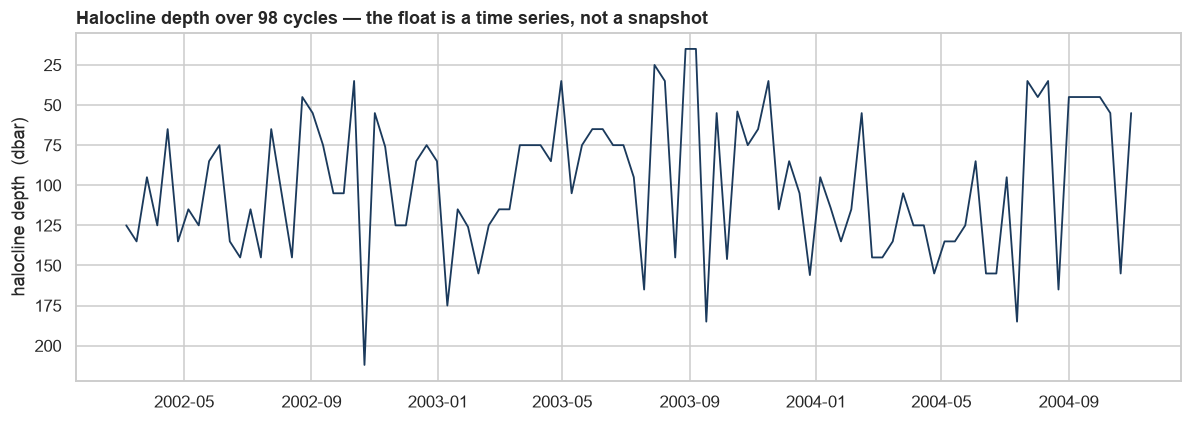

In [9]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(juld, hal, lw=1.2, color="#1b3a5c")
ax.set_ylabel("halocline depth  (dbar)")
ax.set_xlabel("")
ax.set_title("Halocline depth over 98 cycles — the float is a time series, not a snapshot",
             loc="left", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 3. Traps so far

| # | trap | symptom |
|---|---|---|
| 1 | directory listing is HTML, not JSON | a parser, or a regex for `href=` |
| 2 | `N_PARAM` is in `ds.sizes` but unused by `TEMP` | `ValueError` on `isel`, or a wrong answer if you ignore it |
| 3 | QC flags are **bytes** in aggregated files, `int8` in per-cycle files | `== 1` is silently all-False |
| 4 | a single bad QC value makes `.all()` False anyway | count the codes, don't use `.all()` |

## 4. `argopy` is not an option here

The obvious library is `argopy`. It is currently broken against modern `erddapy`:
versions 1.3.1 and 1.4.0 both import `erddapy.erddapy._quote_string_constraints`, a
private symbol removed in `erddapy` 3.x. `argopy` 1.4.0 additionally pins `xarray<=2025.9.0`.

Making it work means pinning `erddapy<3` **and** downgrading xarray — dragging a
working stack backwards for a convenience wrapper. When a library requires that, and the
underlying files are plain netCDF over HTTPS, fetching them directly is the better trade.

## 5. The cost of choosing a float by hand

This notebook uses a float that is not near the site, and the honest reason is that
**there is no index**. Verified, not assumed:

| you would like | what exists |
|---|---|
| `/index/` | 404 |
| `/dac/index/` | 404 |
| `<wmo>_prof_index.txt` | 404 |
| `index/<wmo>.txt` | 404 |

Worse, no *small* file answers "where is this float?":

| file | size | has `LATITUDE`? |
|---|---|---|
| `_meta.nc` | 34,900 B | **no** — configuration only |
| `_tech.nc` | 2,855,864 B | **no** — instrument metadata |
| `_prof.nc` | 689,348 B | yes |

So finding one float near a given site costs 689 KB per candidate, and the coriolis DAC
holds **4,261** floats — about **2.9 GB** to screen it exhaustively. Sampling 711 of them
found none in the north-east Pacific box (30–45 N, 130–115 W).

That is a property of how the archive is laid out, not an oversight, and it is worth
internalising as a design lesson: **if you are about to screen a catalogue by
downloading it, that is the archive telling you its index is missing — plan for it, or
find a source that has one.** ERDDAP and Copernicus both do. This is precisely why the
project kept a fallback ladder rather than committing to the first source that answered.

In [10]:
_fetch.expect("profiles", int(ds.sizes["N_PROF"]), 98)
_fetch.expect("levels", int(ds.sizes["N_LEVELS"]), 92)
_fetch.expect("_prof.nc bytes", S.ARGO_EXPECTED_BYTES, 689348)
_fetch.expect_range("surface temperature", float(np.nanmax(temp)), 15.0, 30.0)
_fetch.expect_range("abyssal temperature", float(np.nanmin(temp)), 0.0, 6.0)
_fetch.expect_range("surface salinity", float(np.nanmax(sal)), 34.0, 38.0)
_fetch.expect_range("halocline depth", float(np.nanmean(hal)), 50.0, 900.0)
print()
print("  0-6 C at depth and 34-38 PSU at the surface are the only physically")
print("  sensible values for an ocean profile. If a profile gives you 4 PSU or")
print("  200 C, you have a scale, a fill-value or a QC problem.")

  ok  profiles: got 98, expected 98
  ok  levels: got 92, expected 92
  ok  _prof.nc bytes: got 689348, expected 689348
  ok  surface temperature: 20.18000030517578 in [15.0, 30.0]
  ok  abyssal temperature: 4.199999809265137 in [0.0, 6.0]
  ok  surface salinity: 36.95899963378906 in [34.0, 38.0]
  ok  halocline depth: 99.37755102040816 in [50.0, 900.0]

  0-6 C at depth and 34-38 PSU at the surface are the only physically
  sensible values for an ocean profile. If a profile gives you 4 PSU or
  200 C, you have a scale, a fill-value or a QC problem.
